# Easy Q4 — 台灣各縣市 2022 年年均地表溫度 CSV

使用 MODIS Terra LST (`MODIS/061/MOD11A1`) 計算台灣各縣市行政邊界內的 2022 年年均白天地表溫度，輸出 CSV。

## 1. 環境設定

In [ ]:
import ee
import pandas as pd
import matplotlib.pyplot as plt

# ee.Authenticate()
ee.Initialize(project='0')

## 2. 載入台灣縣市行政邊界

使用 GEE 公開資產 FAO GAUL Level 2（行政區）篩選台灣各縣市。

In [2]:
# FAO GAUL 2015 Level-1（省/縣市層級），Country code 228 = Taiwan
taiwan_admin = (ee.FeatureCollection('FAO/GAUL/2015/level1')
                .filter(ee.Filter.eq('ADM0_CODE', 228)))

print('縣市數量:', taiwan_admin.size().getInfo())
# 列出縣市名稱
names = taiwan_admin.aggregate_array('ADM1_NAME').getInfo()
print('縣市列表:', names)

縣市數量: 1
縣市列表: ['Administrative unit not available']


## 3. 載入 MODIS LST 並套用品質篩選

In [3]:
START_DATE = '2022-01-01'
END_DATE   = '2023-01-01'  # filterDate exclusive
SCALE_M    = 1000
TARGET_CRS = 'EPSG:4326'

taiwan_bbox = ee.Geometry.Rectangle([119.3, 21.9, 122.1, 25.4])


def mask_modis_lst_quality(image):
    """
    保留 QC_Day bits 0-1 = 0b00 或 0b01 的好資料像素。
    LST DN × 0.02 − 273.15 → °C。
    """
    qc   = image.select('QC_Day')
    good = qc.bitwiseAnd(3).lte(1)
    lst_celsius = (image.select('LST_Day_1km')
                   .multiply(0.02)
                   .subtract(273.15)
                   .updateMask(good)
                   .rename('LST_Celsius'))
    return lst_celsius.copyProperties(image, ['system:time_start'])


lst_col = (ee.ImageCollection('MODIS/061/MOD11A1')
           .filterDate(START_DATE, END_DATE)
           .filterBounds(taiwan_bbox)
           .map(mask_modis_lst_quality))

print('MODIS LST 影像數:', lst_col.size().getInfo())

# 計算全年平均
lst_annual_mean = lst_col.mean().clip(taiwan_bbox)

# 驗證
stats = lst_annual_mean.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=taiwan_bbox,
    scale=SCALE_M,
    maxPixels=int(1e8)
)
print('年均 LST 範圍 (°C):', stats.getInfo())

MODIS LST 影像數: 353
年均 LST 範圍 (°C): {'LST_Celsius_max': 35.20014925373137, 'LST_Celsius_min': 11.872758620689675}


## 4. 各縣市區域統計 → FeatureCollection

In [4]:
# 對每個縣市計算 mean LST
county_stats = lst_annual_mean.reduceRegions(
    collection=taiwan_admin,
    reducer=ee.Reducer.mean(),
    scale=SCALE_M,
    crs=TARGET_CRS
)

# 只保留縣市名稱與均溫
county_stats = county_stats.select(['ADM1_NAME', 'mean'])
print('縣市統計筆數:', county_stats.size().getInfo())

縣市統計筆數: 1


## 5. 匯出 CSV 至 Google Drive

In [5]:
task = ee.batch.Export.table.toDrive(
    collection=county_stats,
    description='Taiwan_County_LST_Annual_2022',
    folder='GEE_Exports',
    fileNamePrefix='Taiwan_County_Annual_LST_2022',
    fileFormat='CSV'
)
task.start()
print('Export task started:', task.id)

Export task started: VQIDRYKQT2CJ4ZS7NEDWGGQH


## 6. 在 Notebook 內直接取得結果（小資料可用 getInfo）

In [6]:
info = county_stats.getInfo()
records = [{
    'county':  f['properties'].get('ADM1_NAME', 'N/A'),
    'annual_mean_lst_celsius': round(f['properties'].get('mean', float('nan')), 2)
} for f in info['features']]

df = pd.DataFrame(records).dropna().sort_values('annual_mean_lst_celsius', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))

# 本地備份 CSV
df.to_csv('Taiwan_County_Annual_LST_2022.csv', index=False, encoding='utf-8-sig')
print('\n已儲存 Taiwan_County_Annual_LST_2022.csv')

Empty DataFrame
Columns: [county, annual_mean_lst_celsius]
Index: []

已儲存 Taiwan_County_Annual_LST_2022.csv


## 7. 視覺化：縣市年均地表溫度長條圖

/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_371824/2530224703.py:12: UserWarning: Glyph 28331 (\N{CJK UNIFIED I

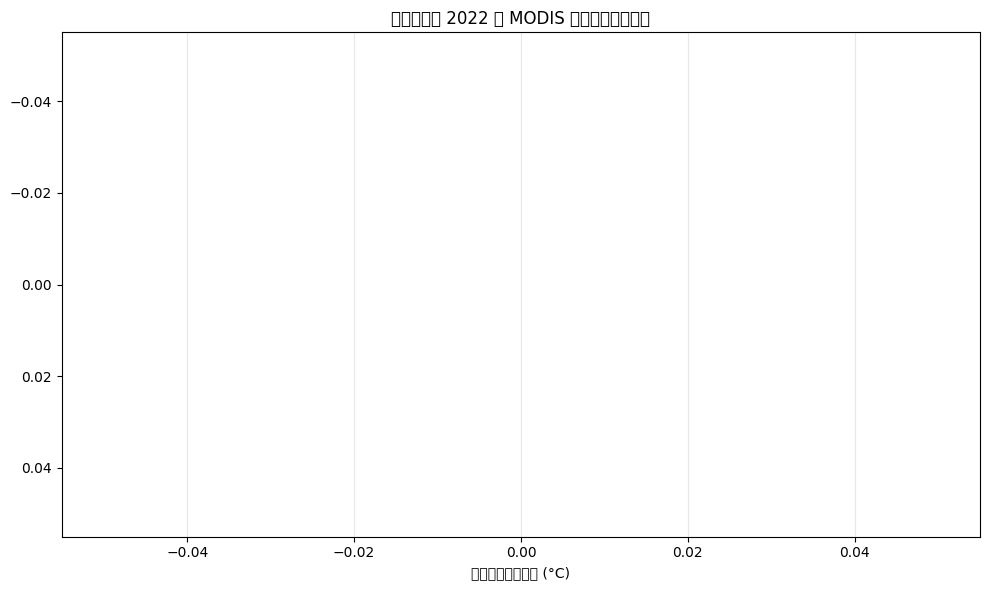

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlBu_r([
    (v - df['annual_mean_lst_celsius'].min()) /
    (df['annual_mean_lst_celsius'].max() - df['annual_mean_lst_celsius'].min())
    for v in df['annual_mean_lst_celsius']
])
ax.barh(df['county'], df['annual_mean_lst_celsius'], color=colors)
ax.set_xlabel('年均白天地表溫度 (°C)')
ax.set_title('台灣各縣市 2022 年 MODIS 年均白天地表溫度')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('taiwan_county_lst_2022.png', dpi=150)
plt.show()